<a href="https://colab.research.google.com/github/sheezariaz2315/sheezariaz2315-urdu-ocr-codesaviours-si26-sheeza/blob/main/Sl26_Week3_sheeza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import torch
from datasets import Dataset
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

drive_base = "/content/drive/MyDrive/Urdu-OCR"
colab_base = "/content/data/raw"

folders = [
    "newspaper",
    "books",
    "signboards",
    "other",
    "synthetic"
]


for folder in folders:
    src = os.path.join(drive_base, folder)
    dst = os.path.join(colab_base, folder)

    os.makedirs(dst, exist_ok=True)

    for file in os.listdir(src):
        shutil.copy2(
            os.path.join(src, file),
            os.path.join(dst, file)
        )



src_csv = os.path.join(drive_base, "labels.csv")
dst_csv = "/content/data/labels.csv"

os.makedirs("/content/data", exist_ok=True)

if os.path.exists(src_csv):
    shutil.copy2(src_csv, dst_csv)
    print("✅ labels.csv copied successfully!")
else:
    print("❌ labels.csv not found in Google Drive.")

print("✅ All images copied successfully!")

✅ labels.csv copied successfully!
✅ All images copied successfully!


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import os
import random

font_path = "/content/NotoNastaliqUrdu-Regular.ttf"

urdu_texts = [
    "میری کتاب بہت دلچسپ ہے",
    "پاکستان ترقی کی راہ پر گامزن ہے",
    "ہمیں درخت لگانے چاہئیں",
    "صفائی نصف ایمان ہے",
    "کامیابی مسلسل محنت سے ملتی ہے",
    "بچے قوم کا مستقبل ہیں",
    "علم انسان کو عزت دیتا ہے",
    "وقت بہت قیمتی ہے",
    "سچائی بہترین پالیسی ہے",
    "ہر مشکل کے بعد آسانی ہے",
    "اتحاد میں طاقت ہے",
    "اپنے والدین کا احترام کریں",
    "زندگی ایک خوبصورت سفر ہے",
    "دوسروں کی مدد کرنا نیکی ہے",
    "پاکستان ہمارا پیارا وطن ہے",
    "مطالعہ علم میں اضافہ کرتا ہے",
    "ایمانداری بہترین خوبی ہے",
    "کھیل صحت کے لیے ضروری ہیں",
    "ہمیشہ سچ بولنا چاہیے",
    "خواب وہی پورے ہوتے ہیں جن کے لیے محنت کی جائے"
]

os.makedirs("data/raw/synthetic", exist_ok=True)

for i, text in enumerate(urdu_texts, start=21):

    bg_color = random.choice([
        "white",
        "#F8F8F8",
        "#FFF8DC",
        "#F5F5DC",
        "#F2F2F2"
    ])

    font_size = random.choice([24, 26, 28, 30, 32])

    font = ImageFont.truetype(font_path, font_size)

    img = Image.new("RGB", (450, 90), color=bg_color)
    draw = ImageDraw.Draw(img)

    draw.text(
        (440, 30),
        text,
        fill="black",
        font=font,
        direction="rtl",
        language="ur",
        anchor="ra"
    )

    img.save(f"data/raw/synthetic/urdu_{i}.png")
    print(f"Generated: urdu_{i}.png")

print("20 new synthetic images generated successfully!")

Generated: urdu_21.png
Generated: urdu_22.png
Generated: urdu_23.png
Generated: urdu_24.png
Generated: urdu_25.png
Generated: urdu_26.png
Generated: urdu_27.png
Generated: urdu_28.png
Generated: urdu_29.png
Generated: urdu_30.png
Generated: urdu_31.png
Generated: urdu_32.png
Generated: urdu_33.png
Generated: urdu_34.png
Generated: urdu_35.png
Generated: urdu_36.png
Generated: urdu_37.png
Generated: urdu_38.png
Generated: urdu_39.png
Generated: urdu_40.png
20 new synthetic images generated successfully!


In [ ]:
import csv

csv_path = "/content/drive/MyDrive/Urdu-OCR/labels.csv"
df = pd.read_csv(csv_path)

labels=[
    {"image": "data/raw/books/books21.png", "text": """مولانا صفی الرحمن مبارک پوری ۶ جون ۱۹۴۳ء کو ہندوستان کے صوبہ اتر پردیش کے ضلع اعظم گڑھ کے ایک قصبہ مبارک پور کے قریب واقع گاؤں حسین آباد میں پیدا ہوئے۔ انھوں نے قرآن پاک کی تعلیم اپنے دادا اور چچا سے حاصل کی۔ ۱۹۳۸ء میں مدرسہ عربیہ دارالتعليم مبارک پور میں داخلہ لے کر عربی اور فارسی کی تعلیم کا آغاز کیا۔ ۱۹۵۲ء میں مدرسہ احیاء العلوم مبارک پور میں داخل ہوئے اور دو سال بعد مزید تعلیم کے لیے مدرسہ فیض عام مئو چلے گئے۔ سات سالہ تعلیمی دور کے بعد سندِ فضیلت حاصل کی۔ ۱۹۵۹ء میں مولوی اور ۱۹۶۰ء میں عالم کی اسناد حاصل کیں۔ تقریباً اٹھائیس سال مختلف مدارس اور جامعات میں تدریس کی۔ مولانا صفی الرحمن کی شہرت ان کی کتاب الرحیق المختوم کی وجہ سے ہوئی جو سیرتِ نبوی ﷺ پر ایک مستند کتاب ہے۔ ۱۹۷۶ء میں اس کتاب نے رابطہ عالم اسلامی کے عالمی مقابلے میں اول انعام حاصل کیا۔"""},
    {"image": "data/raw/books/books22.png", "text": """قدرت اللہ شہاب گلگت میں پیدا ہوئے۔ ابتدائی تعلیم گلگت اور جموں و کشمیر میں حاصل کی جبکہ اعلیٰ تعلیم گورنمنٹ کالج لاہور سے ایم اے انگریزی کی صورت میں مکمل کی۔ ۱۹۴۱ء میں انڈین سول سروس کا امتحان امتیازی حیثیت سے پاس کیا اور ریاست جموں و کشمیر کے پہلے مسلمان آئی سی ایس افسر بنے۔ قیام پاکستان کے بعد مختلف اہم سرکاری عہدوں پر خدمات انجام دیں جن میں سیکریٹری جنرل حکومت آزاد کشمیر، ڈپٹی کمشنر، سیکریٹری اطلاعات، سیکریٹری تعلیم اور دیگر عہدے شامل ہیں۔ وہ ہالینڈ میں پاکستان کے سفیر بھی رہے اور پاکستان رائٹرز گلڈ کے قیام میں اہم کردار ادا کیا۔"""},
    {"image": "data/raw/books/books23.png", "text": """وہ کھانے پینے میں انتہائی سادہ مزاج تھیں۔ ان کی پسندیدہ غذا مکئی کی روٹی اور دھنیے پودینے کی چٹنی تھی۔ ہر نوالے پر اللہ کا شکر ادا کرتیں، سادہ چائے پیتیں اور عموماً ایک وقت کا کھانا کھاتیں۔ دوسروں کو خوشی سے کھاتے دیکھ کر دعا دیتیں اور ہمیشہ دوسروں کی بھلائی مانگتیں۔ اپنے بچوں کو بھی اللہ کی امانت سمجھتی تھیں اور کبھی انہیں اپنا کہہ کر فخر نہیں کیا۔"""},
    {"image": "data/raw/books/books24.png", "text": """اے بادشاہ! آپ کے ملک میں ہمارے کچھ نوجوان آ گئے ہیں جنہوں نے اپنی قوم کا دین چھوڑ دیا ہے مگر آپ کا دین بھی قبول نہیں کیا بلکہ ایک نیا دین اختیار کر لیا ہے۔ ان کے والدین اور قبیلے کے لوگوں نے ہمیں بھیجا ہے تاکہ آپ انہیں واپس ہمارے حوالے کر دیں کیونکہ وہ ان کے حالات کو بہتر جانتے ہیں۔ دونوں کی بات سننے کے بعد بطریقوں نے بادشاہ سے کہا کہ ان نوجوانوں کو واپس ان کے حوالے کر دینا چاہیے۔"""},
    {"image": "data/raw/books/books25.png", "text": """انٹرنیٹ کی مدد سے امجد اسلام امجد کا ڈراما وارث دیکھیں اور اس میں پیش کیے گئے سماجی، اخلاقی اور نفسیاتی مسائل پر اپنی تنقیدی رائے لکھیں۔ جوڑوں کی صورت میں ڈراما رستم اور سہراب کے مکالموں کو جذبات اور تاثر کے ساتھ ڈرامائی انداز میں پیش کریں۔"""},
    {"image": "data/raw/books/books26.png", "text": """کتاب میز پر رکھو۔ وہ رات تک پڑھتا رہا۔ اس سبق میں حروفِ جار کی مثالیں دی گئی ہیں جن میں لفظ 'پر' اور 'تک' کا استعمال جملوں کے اندر دکھایا گیا ہے۔"""},
    {"image": "data/raw/books/books27.png", "text": """یوسفی صاحب نے ابتدائی تعلیم گھر پر حاصل کی اور عربی، فارسی اور دینیات پڑھی۔ انٹرمیڈیٹ اور بی اے میں نمایاں کامیابی حاصل کرنے کے بعد علی گڑھ یونیورسٹی سے ایم اے فلسفہ کیا۔ پاکستان آنے کے بعد مسلم کمرشل بینک میں ملازمت اختیار کی اور پاکستان بینکنگ کونسل کے چیئرمین بنے۔ مشتاق احمد یوسفی اپنی شگفتہ مزاح نگاری، منفرد اسلوب، تہذیبی شعور اور روزمرہ زندگی کے موضوعات پر گہری بصیرت کے باعث اردو ادب میں منفرد مقام رکھتے ہیں۔"""},
    {"image": "data/raw/books/books28.png", "text": """سرسید احمد خان نے عبد صاحب کی صلاحیت دیکھ کر انہیں وظیفہ دے کر علی گڑھ بلا لیا جہاں انہوں نے تعلیم حاصل کی اور بعد ازاں لیکچرر مقرر ہوئے۔ سرسید چاہتے تھے کہ وہ انگلستان جا کر آئی سی ایس کا امتحان دیں لیکن والدہ کی خواہش پر انہوں نے وظیفہ واپس کر دیا۔ اس فیصلے پر سرسید احمد خان کو بہت افسوس اور غصہ ہوا مگر عبد صاحب اپنے فیصلے پر قائم رہے۔"""},
    {"image": "data/raw/books/books29.png", "text": """گرد کے قریب پہنچنے پر ایک بوڑھا شخص نمودار ہوا جس نے پھٹی ہوئی پگڑی، پیوند لگی شلوار اور بوسیدہ قمیص پہن رکھی تھی۔ اس کا چہرہ گرد آلود اور پاؤں ننگے تھے۔ وہ تیزی سے عمارت کی طرف بڑھا لیکن دروازے پر موجود نوجوان نے اسے روک کر پوچھا کہ آپ پہلے کہاں تھے؟"""},
    {"image": "data/raw/books/books30.png", "text": """سبق کے آغاز میں افسانہ نگار غوث بہار اور مترجم غنی پرواز کا تعارف کرایا جائے۔ طلبہ کو بلوچی ادب اور اس کے اردو تراجم کی اہمیت سے آگاہ کیا جائے۔ افسانے کے عنوان محشر، کردار نگاری، ماحول، سماجی پس منظر اور اخلاقی پیغام پر گفتگو کرائی جائے۔"""},
    {"image": "data/raw/books/books31.png", "text": """تحریکِ پاکستان کے پس منظر اور قراردادِ لاہور کی اہمیت کو سمجھنا، مینارِ پاکستان کی قومی و تاریخی اہمیت سے آگاہی حاصل کرنا، قومی یادگاروں کے احترام کا شعور پیدا کرنا، ادبی نثر کے اسلوب اور فکری گہرائی کو سمجھنا، اور مختار مسعود کی شخصیت و ادبی خدمات سے روشناس ہونا۔"""},
    {"image": "data/raw/books/books32.png", "text": """کافی کی خوشبو اور ذائقے کے بارے میں دو افراد کے درمیان مزاحیہ انداز میں گفتگو کی گئی ہے جس میں حسِ شامہ، ذوق اور روزمرہ زندگی کے دلچسپ پہلوؤں کو بیان کیا گیا ہے۔"""},
    {"image": "data/raw/books/books33.png", "text": """رستم بارگاہِ الٰہی میں دعا کرتا ہے کہ اسے دوبارہ جوانی، طاقت اور شجاعت عطا کی جائے تاکہ وہ اپنی ذمہ داریاں بہتر طریقے سے ادا کر سکے۔"""},
    {"image": "data/raw/books/books34.png", "text": """رستم اور سہراب کے درمیان شدید جنگ ہوتی ہے۔ غرور، طاقت اور تقدیر کے موضوعات نمایاں ہوتے ہیں اور آخر میں رستم سہراب کے سینے میں خنجر گھونپ دیتا ہے۔"""},
    {"image": "data/raw/books/books35.png", "text": """آغا حشر کاشمیری اردو کے عظیم ڈرامہ نگار تھے۔ ان کے مشہور ڈراموں میں رستم و سہراب، یہودی کی لڑکی، آنکھ کا نشہ، خوابِ ہستی اور دیگر شامل ہیں۔ ان کی تحریروں میں جاندار مکالمے، جذبات اور معاشرتی مسائل کی عکاسی ملتی ہے۔"""},
    {"image": "data/raw/books/books36.png", "text": """مشتاق احمد یوسفی کی شخصیت اور مزاح نگاری پر روشنی ڈالی جائے، طلبہ سے درست تلفظ اور روانی کے ساتھ بلند خوانی کروائی جائے، اور طنز و مزاح کے پردے میں پوشیدہ معاشرتی پہلوؤں کو سمجھایا جائے۔"""},
    {"image": "data/raw/books/books37.png", "text": """رموزِ اوقاف میں ختمہ جملے کے اختتام پر استعمال ہوتا ہے جبکہ سکتہ مختصر وقفے یا فہرست میں مختلف اشیاء کو الگ کرنے کے لیے استعمال کیا جاتا ہے۔"""},
    {"image": "data/raw/books/books38.png", "text": """کعبۃ اللہ کی عظمت، اذانوں کی گونج، اللہ تعالیٰ کی کبریائی، رحمت اور دعا کی قبولیت کو خوبصورت منظوم انداز میں بیان کیا گیا ہے۔"""},
    {"image": "data/raw/books/books39.png", "text": """لندن سے لاہور جانے والی پرواز میں ایک نوجوان مسافر اور ایک خاتون کے درمیان خاموشی، سکون اور باہمی احترام پر مبنی دلچسپ واقعہ بیان کیا گیا ہے جہاں خاتون اس کی سہولت کے لیے روشنی بند کر دیتی ہیں۔"""},
    {"image": "data/raw/books/books40.png", "text": """لندن سے لاہور کے سفر کے دوران ایک خاتون اور نوجوان مسافر کے درمیان ادب، شائستگی، سکون اور باہمی احترام پر مبنی گفتگو پیش کی گئی ہے جس میں دوسروں کی سہولت کا خیال رکھنے کی اہمیت اجاگر کی گئی ہے۔"""},

    {"image": "data/raw/news/news021.png", "text": """کویت نے پاکستان کے ساتھ دفاعی تعاون کے معاہدے کو شاہی فرمان کے ذریعے منظور کر لیا ہے۔ اس معاہدے کے تحت فوجی تربیت، انٹیلی جنس، لاجسٹکس، دفاعی ٹیکنالوجی، تحقیق اور مہارت کے تبادلے میں تعاون کیا جائے گا۔ پاکستانی سفیر کے مطابق اس معاہدے کا مقصد دونوں ممالک کے درمیان دفاعی تعاون اور علاقائی امن کو فروغ دینا ہے۔"""},
    {"image": "data/raw/news/news022.jpg", "text": """راولا کوٹ میں ہونے والی جھڑپوں کے بعد میرپور میں بھی عوامی ایکشن کمیٹی کے کارکنوں اور پولیس کے درمیان تصادم ہوا جس میں کم از کم ایک شخص جاں بحق ہو گیا۔ آزاد کشمیر میں احتجاج اور سیکیورٹی اہلکاروں کے درمیان کشیدگی کے باعث حالات مزید خراب ہو گئے۔"""},
    {"image": "data/raw/news/news023.png", "text": """محکمہ موسمیات نے ملک میں شدید سردی اور غیر معمولی موسم سے متعلق افواہوں کی تردید کرتے ہوئے کہا ہے کہ جدید موسمیاتی ماڈلز کے مطابق درجہ حرارت معمول کے مطابق رہنے کا امکان ہے۔"""},
    {"image": "data/raw/news/news024.png", "text": """تحریک لبیک پاکستان کے سربراہ سعد رضوی اور ان کے بھائی کی گمشدگی کے حوالے سے بتایا گیا ہے کہ وہ ریاستی تحویل میں نہیں بلکہ آزاد کشمیر میں موجود ہیں۔ قانون نافذ کرنے والے اداروں نے ان کی گرفتاری کی خبروں کی تردید کی ہے۔"""},
    {"image": "data/raw/news/news025.png", "text": """چین نے شکسگام اور کشمیر کے حوالے سے بھارت کے دعوے کو مسترد کرتے ہوئے کہا ہے کہ پاکستان اور چین کے درمیان سرحدی معاہدہ قانونی اور درست ہے اور دونوں ممالک کو اپنی سرحدوں کے تعین کا مکمل حق حاصل ہے۔"""},
    {"image": "data/raw/news/news026.jpg", "text": """پاکستان اور متحدہ عرب امارات کے درمیان پری امیگریشن کلیئرنس معاہدے پر اتفاق ہو گیا ہے۔ اس سہولت کے تحت پاکستانی مسافر یو اے ای پہنچنے کے بعد طویل امیگریشن کارروائی سے بچ سکیں گے۔ پہلے مرحلے میں کراچی سے سفر کرنے والے مسافر اس سہولت سے فائدہ اٹھائیں گے۔"""},
    {"image": "data/raw/news/news027.jpg", "text": """عروج اورنگزیب نے کہا کہ لاپتہ افراد کے لیے آواز اٹھانے والوں کو سخت سزاؤں کا سامنا کرنا پڑا۔ انہوں نے ڈاکٹر ماہ رنگ بلوچ، علی وزیر اور آزاد کشمیر میں احتجاج پر پابندی کا ذکر کرتے ہوئے اظہارِ رائے کی آزادی پر سوالات اٹھائے۔"""},
    {"image": "data/raw/news/news028.png", "text": """سوشل میڈیا پر پاکستان کی 2019 کی ایک پرانی ویڈیو کو بھارت میں ہونے والے سی اے اے احتجاج سے جوڑ کر شیئر کیا جا رہا ہے۔ اس کے ذریعے مختلف ممالک میں نوجوانوں کے احتجاج اور سماجی تبدیلی پر بحث کی جا رہی ہے۔"""},
    {"image": "data/raw/news/news029.png", "text": """مراد آباد کی عدالت نے محمد علی جوہر یونیورسٹی کی 38 عمارتوں کو گرانے کی کارروائی کو حتمی سماعت تک روک دیا ہے۔ یونیورسٹی کے طلبہ اور ملازمین کو اپنی تعلیم اور روزگار کے مستقبل کے بارے میں شدید تشویش ہے۔"""},
    {"image": "data/raw/news/news030.jpg", "text": """جوہر یونیورسٹی کی طالبہ اقرا نے کہا کہ اگر یونیورسٹی کو منہدم کر دیا گیا تو اس کی تعلیم ادھوری رہ جائے گی اور گھر والے اسے واپس بلا کر شادی کر دیں گے۔ اس فیصلے کے خدشے نے طلبہ میں بے چینی پیدا کر دی ہے۔"""},
    {"image": "data/raw/news/news031.png", "text": """پاکستان اور کویت کے درمیان 11 جون 2023ء کو دفاعی تعاون کا معاہدہ طے پایا تھا۔ تین سال بعد کویت نے اس معاہدے کی شاہی فرمان کے ذریعے منظوری دے دی۔ اس معاہدے سے دونوں ممالک کے درمیان دفاعی تعاون، تربیت اور باہمی تعلقات مزید مضبوط ہوں گے۔"""},
    {"image": "data/raw/news/news032.jpg", "text": """ایران نے جنوری کے احتجاج سے متعلق مقدمے میں مزید دو افراد کو سیکیورٹی اہلکاروں کے قتل کے الزام میں پھانسی دے دی۔ اس مقدمے میں مجموعی طور پر بارہ افراد کو سزائے موت سنائی گئی تھی جبکہ احتجاج کے بعد اب تک متعدد افراد کو پھانسی دی جا چکی ہے۔"""},
    {"image": "data/raw/news/news033.png", "text": """وفاقی حکومت نے پیٹرول اور ہائی اسپیڈ ڈیزل کی قیمتوں میں اضافہ کر دیا ہے۔ نئی قیمتوں کے مطابق پیٹرول اور ڈیزل دونوں مہنگے ہو گئے ہیں اور حکومت نے اس حوالے سے باقاعدہ نوٹیفکیشن جاری کر دیا ہے۔"""},
    {"image": "data/raw/news/news034.jpg", "text": """امریکہ اور ایران کے درمیان ممکنہ معاہدے کی امید پر عالمی منڈی میں خام تیل کی قیمتوں میں نمایاں کمی ریکارڈ کی گیا۔ برینٹ اور امریکی خام تیل دونوں کی قیمتوں میں پانچ فیصد سے زیادہ کمی آئی۔"""},
    {"image": "data/raw/news/news035.jpg", "text": """وفاقی ادارہ شماریات کے مطابق ہفتہ وار مہنگائی میں اضافہ ریکارڈ کیا گیا۔ مختلف اشیائے ضروریہ خصوصاً ٹماٹر، پیٹرول، ڈیزل اور انڈوں کی قیمتوں میں اضافہ ہوا جبکہ چند اشیاء کی قیمتوں میں کمی بھی دیکھی گئی۔"""},
    {"image": "data/raw/news/news036.jpg", "text": """پاکستان بزنس فورم نے پیٹرولیم مصنوعات کی قیمتوں میں حالیہ اضافے پر تشویش کا اظہار کرتے ہوئے حکومت سے پیٹرولیم لیوی میں کمی اور آئل مارکیٹنگ کمپنیوں کے مارجن پر نظرثانی کا مطالبہ کیا ہے۔"""},
    {"image": "data/raw/news/news037.jpg", "text": """آل پاکستان جیمز اینڈ جیولرز ایسوسی ایشن کے مطابق ملکی اور عالمی مارکیٹ میں سونے کی قیمت میں نمایاں کمی ہوئی ہے۔ فی تولہ اور دس گرام سونے کی قیمت کم ہونے کے بعد نئی قیمتیں جاری کر دی گئی ہیں۔"""},
    {"image": "data/raw/news/news038.jpg", "text": """عمان نے آبنائے ہرمز کے انتظام کے لیے ایران کو مشترکہ علاقائی نظام کی تجویز دی ہے تاکہ خطے میں کشیدگی کم ہو اور سمندری راستوں کی حفاظت کو یقینی بنایا جا سکے۔"""},
    {"image": "data/raw/news/news039.png", "text": """پاکستان اسٹاک ایکسچینج میں کے ایس ای 100 انڈیکس نے نئی تاریخی بلند ترین سطح حاصل کر لی۔ کاروبار کے دوران انڈیکس میں ریکارڈ پوائنٹس کا اضافہ دیکھنے میں آیا۔"""},
    {"image": "data/raw/news/news040.jpg", "text": """وفاقی کابینہ نے پیٹرول ڈیلرز اور آئل مارکیٹنگ کمپنیوں کے منافع میں اضافے کی منظوری مؤخر کر دی ہے۔ حکومت نے اس فیصلے کو مکمل ڈیجیٹلائزیشن سے مشروط کرتے ہوئے فوری طور پر نافذ نہ کرنے کا فیصلہ کیا۔"""},

    {"image": "data/raw/signboard/signboard21.png", "text": """زندگی ہماری اور پریشانی آپ کو؟"""},
    {"image": "data/raw/signboard/signboard22.png", "text": """کاہلی آگے ٹوٹے"""},
    {"image": "data/raw/signboard/signboard23.png", "text": """پھول توڑنا منع ہے"""},
    {"image": "data/raw/signboard/signboard24.png", "text": """دماغ شارٹ نہ کریں شکریہ"""},
    {"image": "data/raw/signboard/signboard25.png", "text": """آپ کو کیا؟"""},
    {"image": "data/raw/signboard/signboard26.png", "text": """شارع نوبار"""},
    {"image": "data/raw/signboard/signboard27.png", "text": """مبارکباد پیش کرتے ہیں"""},
    {"image": "data/raw/signboard/signboard28.png", "text": """ایصالِ ثواب"""},
    {"image": "data/raw/signboard/signboard29.png", "text": """چرس یا محبت؟"""},
    {"image": "data/raw/signboard/signboard30.png", "text": """بُدھُ"""},
    {"image": "data/raw/signboard/signboard31.png", "text": """کلاتھ ہاؤس"""},
    {"image": "data/raw/signboard/signboard32.png", "text": """خوش آمدید"""},
    {"image": "data/raw/signboard/signboard33.png", "text": """لاہور"""},
    {"image": "data/raw/signboard/signboard34.png", "text": """زخمِ حیات"""},
    {"image": "data/raw/signboard/signboard35.png", "text": """ہائے گرمی"""},
    {"image": "data/raw/signboard/signboard36.png", "text": """زیادہ فری مت ہو"""},
    {"image": "data/raw/signboard/signboard37.png", "text": """ڈبل فلم نئی اردو فلم گیت مالا ہمراہ رات کو بھی عید کے دن ہے حسینہ جان لیوا"""},
    {"image": "data/raw/signboard/signboard38.png", "text": """اجتماع"""},
    {"image": "data/raw/signboard/signboard39.png", "text": """چل نکل"""},
    {"image": "data/raw/signboard/signboard40.png", "text": """وٹ پینی"""},

    {"image": "data/raw/synthetic/urdu_21.png", "text": """میری کتاب بہت دلچسپ ہے"""},
    {"image": "data/raw/synthetic/urdu_22.png", "text": """پاکستان ترقی کی راہ پر گامزن ہے"""},
    {"image": "data/raw/synthetic/urdu_23.png", "text": """ہمیں درخت لگانے چاہئیں"""},
    {"image": "data/raw/synthetic/urdu_24.png", "text": """صفائی نصف ایمان ہے"""},
    {"image": "data/raw/synthetic/urdu_25.png", "text": """کامیابی مسلسل محنت سے ملتی ہے"""},
    {"image": "data/raw/synthetic/urdu_26.png", "text": """بچے قوم کا مستقبل ہیں"""},
    {"image": "data/raw/synthetic/urdu_27.png", "text": """علم انسان کو عزت دیتا ہے"""},
    {"image": "data/raw/synthetic/urdu_28.png", "text": """وقت بہت قیمتی ہے"""},
    {"image": "data/raw/synthetic/urdu_29.png", "text": """سچائی بہترین پالیسی ہے"""},
    {"image": "data/raw/synthetic/urdu_30.png", "text": """ہر مشکل کے بعد آسانی ہے"""},
    {"image": "data/raw/synthetic/urdu_31.png", "text": """اتحاد میں طاقت ہے"""},
    {"image": "data/raw/synthetic/urdu_32.png", "text": """اپنے والدین کا احترام کریں"""},
    {"image": "data/raw/synthetic/urdu_33.png", "text": """زندگی ایک خوبصورت سفر ہے"""},
    {"image": "data/raw/synthetic/urdu_34.png", "text": """دوسروں کی مدد کرنا نیکی ہے"""},
    {"image": "data/raw/synthetic/urdu_35.png", "text": """پاکستان ہمارا پیارا وطن ہے"""},
    {"image": "data/raw/synthetic/urdu_36.png", "text": """مطالعہ علم میں اضافہ کرتا ہے"""},
    {"image": "data/raw/synthetic/urdu_37.png", "text": """ایمانداری بہترین خوبی ہے"""},
    {"image": "data/raw/synthetic/urdu_38.png", "text": """کھیل صحت کے لیے ضروری ہیں"""},
    {"image": "data/raw/synthetic/urdu_39.png", "text": """ہمیشہ سچ بولنا چاہیے"""},
    {"image": "data/raw/synthetic/urdu_40.png", "text": """خواب وہی پورے ہوتے ہیں جن کے لیے محنت کی جائے"""},

    {"image": "data/raw/other/21.png", "text": """تعلیمات پر عمل نہ کرتا تو سیاست میں قدم رکھنے"""},
    {"image": "data/raw/other/22.png", "text": """کے بعد میں بھی چوری چکاری اور لوٹ مار میں لگ جاتا"""},
    {"image": "data/raw/other/23.png", "text": """اور دیگر سیاستدانوں کی طرح آج میں بھی کھرب پتی"""},
    {"image": "data/raw/other/24.png", "text": """چکا ہوتا مگر میری اللہ تعالیٰ سے یہی دعا ہے"""},
    {"image": "data/raw/other/25.png", "text": """کہ وہ مجھے سرکار دو عالم ﷺ کی سیرت طیبہ پر قدم بہ"""},
    {"image": "data/raw/other/26.png", "text": """قدم چلنے کی توفیق عطا فرمائے۔ الطاف حسین نے کہا کہ"""},
    {"image": "data/raw/other/27.png", "text": """میں نے شروع دن سے ہی قرآن مجید اور سرکار دو عالم ﷺ"""},
    {"image": "data/raw/other/28.png", "text": """کی تعلیمات کے مطابق امن، سلامتی، احترامِ انسانیت اور اعتدال"""},
    {"image": "data/raw/other/29.png", "text": """پسندی کا درس دیا، میرا ہمیشہ یہی کہنا ہے کہ چاہے کوئی"""},
    {"image": "data/raw/other/30.png", "text": """کسی بھی مذہب، فقہ یا مسلک کا ماننے والا ہو، سب کا احترام"""},
    {"image": "data/raw/other/31.png", "text": """کرو، کسی سے نفرت نہ کرو، سب کو جینے کا حق ہے، آپ کا جو بھی"""},
    {"image": "data/raw/other/32.png", "text": """کا قبضہ کرنا چاہتے ہیں لیکن جب تک ایم کیو ایم"""},
    {"image": "data/raw/other/33.png", "text": """ہم آہنگی کی فضاء کو تباہ کر کے یہاں جنونیت اور مذہبی انتہا پسندی"""},
    {"image": "data/raw/other/34.png", "text": """خصوصاً سندھ میں مذہبی رواداری اور فرقہ وارانہ"""},
    {"image": "data/raw/other/35.png", "text": """اور مسلک کا عقیدہ ہو آپ اس کے مطابق اللہ کی عبادت"""},
    {"image": "data/raw/other/36.png", "text": """کیجئے، کون صحیح ہے کون غلط، کون حق پر ہے کون نہیں"""},
    {"image": "data/raw/other/37.png", "text": """ہے، کون جنت میں اور کون دوزخ میں جائے گا اس کا فیصلہ"""},
    {"image": "data/raw/other/38.png", "text": """انسان نہیں بلکہ روزِ محشر اللہ رب العزت کرے گا، جو سمجھتا ہے کہ"""},
    {"image": "data/raw/other/39.png", "text": """میری تعلیم غلط ہے وہ بے شک مجھے چھوڑ دے مگر میں"""},
    {"image": "data/raw/other/40.png", "text": """اپنے راستے کو نہیں چھوڑوں گا۔ انہوں نے کہا کہ مذہبی"""}
]

all_new_data = labels
df = pd.concat([df, new_df], ignore_index=True)

df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("All labels appended successfully!")
print(df.tail())

All labels appended successfully!
                     image                                               text
195  data/raw/other/36.png  کیجئے، کون صحیح ہے کون غلط، کون حق پر ہے کون نہیں
196  data/raw/other/37.png  ہے، کون جنت میں اور کون دوزخ میں جائے گا اس کا...
197  data/raw/other/38.png  انسان نہیں بلکہ روزِ محشر اللہ رب العزت کرے گا...
198  data/raw/other/39.png    میری تعلیم غلط ہے وہ بے شک مجھے چھوڑ دے مگر میں
199  data/raw/other/40.png  اپنے راستے کو نہیں چھوڑوں گا۔ انہوں نے کہا کہ ...


In [8]:
import shutil
import os

os.makedirs(os.path.dirname("/content/data/labels.csv"), exist_ok=True)

shutil.copy(
    "/content/drive/MyDrive/Urdu-OCR/labels.csv",
    "/content/data/labels.csv"
)

print("Updated labels.csv copied to Colab.")

Updated labels.csv copied to Colab.


In [9]:
import pandas as pd

df = pd.read_csv("/content/data/labels.csv")

print(len(df))
df.sample(5)

200


,image,text
37,books/books38.png,کعبۃ اللہ کی عظمت، اذانوں کی گونج، اللہ تعالیٰ...
88,signboards/signboard9.png,ٹریفک سائنز کی تیاری
109,signboards/signboard30.png,بُدھُ
143,synthetic/urdu_24.png,صفائی نصف ایمان ہے
53,newspaper/news014.png,حملے کی صورت میں ایران کی اسرائیل اور امریکی ا...


In [10]:
import re

def sort_key(path):
    parts = path.split("/")
    folder = parts[-2]
    filename = parts[-1].split(".")[0]
    match = re.search(r"\d+", filename)
    number = int(match.group()) if match else 9999

    return (folder_order[folder], number)

In [ ]:
import pandas as pd
import re

csv_path = "/content/drive/MyDrive/Urdu-OCR/labels.csv"

df = pd.read_csv(csv_path)

df["image"] = df["image"].str.replace("/news/", "/newspaper/", regex=False)
df["image"] = df["image"].str.replace("/signboard/", "/signboards/", regex=False)


folder_order = {
    "books": 0,
    "newspaper": 1,
    "signboards": 2,
    "synthetic": 3,
    "other": 4
}

def sort_key(path):
    parts = path.split("/")
    folder = parts[-2]
    filename = parts[-1].split(".")[0]
    match = re.search(r"\d+", filename)
    number = int(match.group()) if match else

    return (folder_order[folder], number)

df = df.sort_values(
    by="image",
    key=lambda col: col.map(sort_key)
).reset_index(drop=True)

# Save
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("✅ CSV sorted successfully!")
print(df.head(50))

✅ CSV sorted successfully!
                             image  \
0      data/raw/books/books001.png   
1      data/raw/books/books002.png   
2      data/raw/books/books003.png   
3      data/raw/books/books004.png   
4      data/raw/books/books005.png   
5      data/raw/books/books006.png   
6      data/raw/books/books007.png   
7      data/raw/books/books008.png   
8      data/raw/books/books009.png   
9      data/raw/books/books010.png   
10     data/raw/books/books011.png   
11     data/raw/books/books012.png   
12     data/raw/books/books013.png   
13     data/raw/books/books014.png   
14     data/raw/books/books015.png   
15     data/raw/books/books016.png   
16     data/raw/books/books017.png   
17     data/raw/books/books018.png   
18     data/raw/books/books019.png   
19     data/raw/books/books020.png   
20      data/raw/books/books21.png   
21      data/raw/books/books22.png   
22      data/raw/books/books23.png   
23      data/raw/books/books24.png   
24      data/raw/books/

In [ ]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/Urdu-OCR/labels.csv",
    "/content/data/labels.csv"
)

print("Updated labels.csv copied to Colab.")

Updated labels.csv copied to Colab.


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Urdu-OCR/labels.csv")


train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


train_df.to_csv("/content/drive/MyDrive/Urdu-OCR/train.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("/content/drive/MyDrive/Urdu-OCR/val.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("/content/drive/MyDrive/Urdu-OCR/test.csv", index=False, encoding="utf-8-sig")

Train: 160
Validation: 20
Test: 20


In [8]:
train_df.head()

,image,text
79,newspaper/news040.png,وفاقی کابینہ نے پیٹرول ڈیلرز اور آئل مارکیٹنگ ...
197,other/38.png,انسان نہیں بلکہ روزِ محشر اللہ رب العزت کرے گا...
38,books/books39.png,لندن سے لاہور جانے والی پرواز میں ایک نوجوان م...
24,books/books25.png,انٹرنیٹ کی مدد سے امجد اسلام امجد کا ڈراما وار...
122,synthetic/urdu_3.png,تعلیم ہر انسان کا حق ہے


In [9]:
val_df.head()

,image,text
115,signboards/signboard36.png,زیادہ فری مت ہو
182,other/23.png,اور دیگر سیاستدانوں کی طرح آج میں بھی کھرب پتی
15,books/books16.png,زندگی کو دوسروں سے مت ناپو
132,synthetic/urdu_13.png,سچ بولنا اچھی عادت ہے
16,books/books17.png,دنیا کو کوئی روزہ دار مکمل سمجھ کر مت اپناؤ


In [12]:
test_df.head()

,image,text
68,newspaper/news029.png,مراد آباد کی عدالت نے محمد علی جوہر یونیورسٹی ...
56,newspaper/news017.png,دو روز میں ٹیسٹ میچ ختم، آئی سی سی نے میلبورن ...
177,other/18.png,میں تشدد اس وقت شروع ہوا جب 500 کے لگ بھگ
84,signboards/signboard5.png,اسلام آباد، لاہور، کراچی، پشاور، کوئٹہ، ملتان
128,synthetic/urdu_9.png,میں پاکستانی ہوں مجھے فخر ہے


In [12]:
train_df.shape
val_df.shape
test_df.shape

(20, 2)

In [13]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Urdu-OCR/labels.csv")

chars = set()

for text in df["text"]:
    chars.update(str(text))

chars = sorted(chars)

print("Total unique characters:", len(chars))
print(chars)

Total unique characters: 115
[' ', '!', "'", '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', 'A', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'U', 'V', 'W', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'q', 'r', 's', 't', 'u', 'w', 'y', '،', '؟', 'ء', 'آ', 'ؤ', 'ئ', 'ا', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ل', 'م', 'ن', 'و', 'ي', 'ً', 'ُ', 'ِ', 'ٰ', 'ٹ', 'پ', 'چ', 'ڈ', 'ڑ', 'ک', 'گ', 'ں', 'ھ', 'ہ', 'ۃ', 'ی', 'ے', '۔', '۰', '۱', '۲', '۳', '۴', '۵', '۶', '۷', '۸', '۹', 'ﷺ']


In [14]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Urdu-OCR/labels.csv")

chars = set()

for text in df["text"]:
    chars.update(str(text))

chars = sorted(chars)

with open("/content/drive/MyDrive/Urdu-OCR/vocab.txt","w",encoding="utf-8") as f:
    for c in chars:
        f.write(c+"\n")

In [15]:
print("Total Images:", len(df))
print("Unique Images:", df["image"].nunique())
print("Duplicate Images:", df["image"].duplicated().sum())
print("Missing Text:", df["text"].isnull().sum())

Total Images: 200
Unique Images: 200
Duplicate Images: 0
Missing Text: 0


In [ ]:
import os

base = "/content/drive/MyDrive/Urdu-OCR"

for root, dirs, files in os.walk(base):
    print(root)
    for f in files:
        print("   ", f)

/content/drive/MyDrive/Urdu-OCR
    labels.csv
    train.csv
    val.csv
    test.csv
    vocab.txt
/content/drive/MyDrive/Urdu-OCR/newspaper
    news001.png
    news006.png
    news007.png
    news008.png
    news009.png
    news010.png
    news011.png
    news012.png
    news016.png
    news017.png
    news018.png
    news019.png
    news020.png
    news013.png
    news014.png
    news015.png
    news003.png
    news002.png
    news004.png
    news005.png
    news022.png
    news021.png
    news031.png
    news030.png
    news029.png
    news028.png
    news027.png
    news026.png
    news025.png
    news024.png
    news023.png
    news040.png
    news039.png
    news038.png
    news037.png
    news036.png
    news035.png
    news034.png
    news033.png
    news032.png
/content/drive/MyDrive/Urdu-OCR/other
    3.png
    4.png
    1.png
    2.png
    8.png
    17.png
    16.png
    20.png
    12.png
    13.png
    7.png
    19.png
    5.png
    11.png
    10.png
    6.png
    9.png
  

In [13]:
import pandas as pd

for file in ["labels.csv", "train.csv", "val.csv", "test.csv"]:

    path = f"/content/drive/MyDrive/Urdu-OCR/{file}"

    df = pd.read_csv(path)

    df["image"] = df["image"].str.replace("data/raw/", "", regex=False)

    df.to_csv(path, index=False, encoding="utf-8-sig")

    print(file, "updated")

labels.csv updated
train.csv updated
val.csv updated
test.csv updated


In [ ]:
import pandas as pd
import re

files = [
    "/content/drive/MyDrive/Urdu-OCR/labels.csv",
    "/content/drive/MyDrive/Urdu-OCR/train.csv",
    "/content/drive/MyDrive/Urdu-OCR/val.csv",
    "/content/drive/MyDrive/Urdu-OCR/test.csv"
]

def fix_path(path):

    path = path.replace(".jpg", ".png")
    path = re.sub(r'books/books0*([1-9]\d*)\.png', r'books/books\1.png', path)
    path = re.sub(r'signboards/signboard0*([1-9]\d*)\.png',
                  r'signboards/signboard\1.png', path)
    path = re.sub(r'synthetic/synthetic0*([1-9]\d*)\.png',
                  r'synthetic/urdu_\1.png', path)
    path = re.sub(r'other/other0*([1-9]\d*)\.png',
                  r'other/\1.png', path)

    return path


for file in files:
    df = pd.read_csv(file)
    df["image"] = df["image"].apply(fix_path)
    df.to_csv(file, index=False, encoding="utf-8-sig")
    print(f"{file} fixed!")

print("✅ Done!")

/content/drive/MyDrive/Urdu-OCR/labels.csv fixed!
/content/drive/MyDrive/Urdu-OCR/train.csv fixed!
/content/drive/MyDrive/Urdu-OCR/val.csv fixed!
/content/drive/MyDrive/Urdu-OCR/test.csv fixed!
✅ Done!


In [14]:
import pandas as pd
import os

df = pd.read_csv("/content/drive/MyDrive/Urdu-OCR/train.csv")

missing = []

for img in df["image"]:
    path = "/content/drive/MyDrive/Urdu-OCR/" + img
    if not os.path.exists(path):
        missing.append(img)

print("Missing:", len(missing))
print(missing[:30])

Missing: 0
[]


In [16]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from datasets import Dataset
import pandas as pd
from PIL import Image

In [ ]:
!pip install \
transformers==4.38.2 \
tokenizers==0.15.2 \
sentencepiece==0.1.99 \
protobuf==5.29.5

In [1]:
import transformers
import tokenizers
import sentencepiece
import google.protobuf

print(transformers.__version__)
print(tokenizers.__version__)
print(sentencepiece.__version__)
print(google.protobuf.__version__)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

4.38.2
0.15.2
0.1.99
5.29.5


In [1]:
import transformers
import peft

print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

Transformers: 4.38.2
PEFT: 0.8.2


In [3]:
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

print("All Imports Successful")

All Imports Successful


In [7]:
processor = TrOCRProcessor.from_pretrained(
    "microsoft/trocr-base-printed"
)

model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-printed"
)

print("Processor & Model Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense

Processor & Model Loaded


In [23]:
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id

model.config.vocab_size = model.config.decoder.vocab_size

print("Model Config Ready")

Model Config Ready


In [9]:
from torch.utils.data import Dataset
from PIL import Image
import os

class UrduOCRDataset(Dataset):

    def __init__(self, df, processor, img_dir="/content/drive/MyDrive/Urdu-OCR/"):
        self.df = df
        self.processor = processor
        self.img_dir = img_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            os.path.join(self.img_dir, row["image"])
        ).convert("RGB")

        encoding = self.processor(
            image,
            text=row["text"],
            padding="max_length",
            truncation=True,
            max_length=64,
            return_tensors="pt"
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(),
            "labels": encoding["labels"].squeeze()
        }

print("Dataset Class Ready")

Dataset Class Ready


In [12]:
dataset = UrduOCRDataset(train_df, processor)
val_dataset = UrduOCRDataset(val_df, processor)
test_dataset = UrduOCRDataset(test_df, processor)

print(len(dataset))
print(len(val_dataset))
print(len(test_dataset))

160
20
20


In [13]:
sample = dataset[0]

print(sample.keys())
print(sample["pixel_values"].shape)
print(sample["labels"].shape)

dict_keys(['pixel_values', 'labels'])
torch.Size([3, 384, 384])
torch.Size([64])


In [14]:
import torch

training_args = Seq2SeqTrainingArguments(
    output_dir="./trocr-urdu",

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    predict_with_generate=True,

    evaluation_strategy="epoch",
    save_strategy="epoch",

    logging_steps=10,

    num_train_epochs=10,

    learning_rate=5e-5,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

print("Training Arguments Ready")

Training Arguments Ready


In [2]:
import transformers
import accelerate

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 4.38.2
Accelerate: 0.27.2


In [19]:
from dataclasses import dataclass
from typing import Any, Dict, List
import torch

@dataclass
class TrOCRDataCollator:

    def __call__(self, features: List[Dict[str, Any]]):

        pixel_values = torch.stack(
            [f["pixel_values"] for f in features]
        )

        labels = torch.stack(
            [f["labels"] for f in features]
        )

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

print("Data Collator Ready")

Data Collator Ready


In [21]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=val_dataset,
    tokenizer=processor.tokenizer,
    data_collator=TrOCRDataCollator()
)

print("Trainer Ready")

Trainer Ready


In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.234400,3.134757
2,3.185400,2.767836
3,3.185500,2.908737
4,2.691200,2.888825
5,3.057400,2.945467
6,2.883700,2.940632
7,3.157600,2.801073
8,3.014700,2.814330
9,2.909900,2.818844
10,3.071900,2.818835


Removed shared tensor {'decoder.output_projection.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


TrainOutput(global_step=800, training_loss=3.0860470223426817, metrics={'train_runtime': 1155.2074, 'train_samples_per_second': 1.385, 'train_steps_per_second': 0.693, 'total_flos': 1.1972563055935488e+18, 'train_loss': 3.0860470223426817, 'epoch': 10.0})

In [26]:
SAVE_PATH = "/content/drive/MyDrive/Urdu-OCR/trocr-urdu-model"

trainer.save_model(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


/content/drive/MyDrive/Urdu-OCR/newspaper/news040.png


(np.float64(-0.5), np.float64(877.5), np.float64(801.5), np.float64(-0.5))

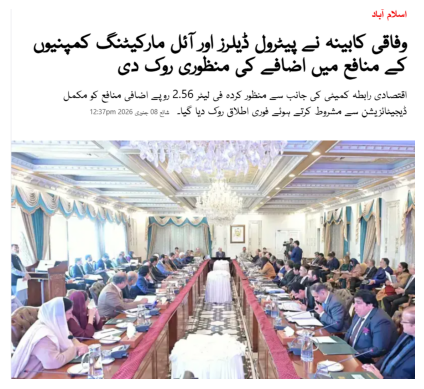

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = os.path.join(
    "/content/drive/MyDrive/Urdu-OCR",
    train_df.iloc[0]["image"]
)

print(image_path)

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")

In [30]:
total_images = len(train_df) + len(val_df) + len(test_df)

print(f"My dataset has {total_images} images and loads correctly.")

My dataset has 200 images and loads correctly.


In [31]:
total_images = len(train_df) + len(val_df) + len(test_df)

print("===== DATASET VERIFICATION =====")
print(f"Train Images      : {len(train_df)}")
print(f"Validation Images : {len(val_df)}")
print(f"Test Images       : {len(test_df)}")
print(f"Total Images      : {total_images}")
print("Status            : Dataset loads correctly.")

===== DATASET VERIFICATION =====
Train Images      : 160
Validation Images : 20
Test Images       : 20
Total Images      : 200
Status            : Dataset loads correctly.
